In [ ]:
!pip install imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import glob
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_dir = "/content/drive/MyDrive/Geolife Trajectories 1.3/Data"

In [ ]:
import os
import pandas as pd
from datetime import datetime
def load_geolife_data(root_dir):
    all_trajectories = []
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        trajectory_path = os.path.join(user_path, 'Trajectory')

        if not os.path.isdir(trajectory_path):
            continue

        for filename in os.listdir(trajectory_path):
            if filename.endswith('.plt'):
                file_path = os.path.join(trajectory_path, filename)
                try:
                    # Read the file, skipping the first 6 lines (header)
                    df = pd.read_csv(file_path, skiprows=6, header=None,
                                     names=['latitude', 'longitude', 'zero', 'altitude', 'date_days', 'date_str', 'time_str'])

                    # Convert date and time strings to datetime objects
                    df['datetime'] = pd.to_datetime(df['date_str'] + ' ' + df['time_str'], format='%Y-%m-%d %H:%M:%S')

                    # Select relevant columns and append the DataFrame directly
                    trajectory_df = df[['latitude', 'longitude', 'altitude', 'datetime']]
                    all_trajectories.append(trajectory_df)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return all_trajectories

trajectories = load_geolife_data(root_dir)
print("Total trajectories:", len(trajectories))

Total trajectories: 18878


In [ ]:
import numpy as np

def extract_features(traj):

    traj = traj.sort_values("datetime")

    lat = traj["latitude"].values
    lon = traj["longitude"].values
    time = traj["datetime"].values.astype('datetime64[s]')

    if len(lat) < 3:
        return None

    # distance between points
    distances = np.sqrt(np.diff(lat)**2 + np.diff(lon)**2)

    total_distance = np.sum(distances)

    # time differences
    time_diff = np.diff(time).astype('timedelta64[s]').astype(float)

    # speed
    speed = distances / (time_diff + 1)

    avg_speed = np.mean(speed)
    max_speed = np.max(speed)
    speed_std = np.std(speed)

    # acceleration
    acceleration = np.diff(speed)
    avg_acceleration = np.mean(acceleration) if len(acceleration) > 0 else 0

    # stop ratio
    stop_ratio = np.sum(speed < 0.5) / len(speed)

    # idle time
    idle_time = np.sum(speed < 0.5)

    # travel time
    travel_time = (time[-1] - time[0]).astype('timedelta64[s]').astype(float)

    # trajectory length
    trajectory_length = len(traj)

    # heading change
    heading_change = np.mean(np.abs(np.diff(lat) + np.diff(lon)))

    return [


    ]

In [ ]:
feature_list = []

for traj in trajectories:
    f = extract_features(traj)
    if f is not None:
        feature_list.append(f)

print("Total feature rows:", len(feature_list))

Total feature rows: 18878


In [ ]:
features_df = pd.DataFrame(feature_list, columns=[
    'distance',
    'avg_speed',
    'max_speed',
    'speed_std',
    'acceleration',
    'stop_ratio',
    'idle_time',
    'travel_time',
    'trajectory_length',
    'heading_change'
])

In [ ]:
features_df.head()

,distance,avg_speed,max_speed,speed_std,acceleration,stop_ratio,idle_time,travel_time,trajectory_length,heading_change
0,12.607735,0.000136,0.000579,0.000068,-3.183683e-09,1.0,45992,97125.0,45993,0.000265
1,0.000084,0.000001,0.000005,0.000001,-3.153429e-07,1.0,14,55.0,15,0.000008
2,0.004215,0.000006,0.000145,0.000019,-1.252627e-06,1.0,117,5985.0,118,0.000039
3,0.000084,0.000001,0.000005,0.000001,-3.153429e-07,1.0,14,55.0,15,0.000008
4,0.000084,0.000001,0.000005,0.000001,-3.153429e-07,1.0,14,55.0,15,0.000008


In [ ]:
features_df["label"].value_counts()

,count
label,
0,17934
1,944


In [ ]:
from scipy.stats import zscore

features_df["speed_z"] = zscore(features_df["max_speed"])
features_df["dist_z"] = zscore(features_df["distance"])

features_df["label"] = (
    (features_df["speed_z"] > 2) |
    (features_df["dist_z"] > 2) |
    (features_df["speed_std"] > features_df["speed_std"].quantile(0.95))
).astype(int)

In [ ]:
X = features_df[[
    'distance',
    'avg_speed',
    'max_speed',
    'speed_std',
    'acceleration',
    'stop_ratio',
    'idle_time',
    'travel_time',
    'trajectory_length',
    'heading_change'
]].values

y = features_df["label"].values

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [ ]:
import numpy as np

np.bincount(y_resampled)

array([17934, 17934])

In [ ]:
X_resampled = X_resampled.reshape(
    X_resampled.shape[0],
    X_resampled.shape[1],
    1
)

In [ ]:
(samples, timesteps, features)

NameError: name 'samples' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D

In [ ]:
input_layer = Input(shape=(X_train.shape[1],1))

x = Conv1D(64,3,activation='relu')(input_layer)
x = MaxPooling1D(2)(x)

x = Conv1D(128,3,activation='relu')(x)
x = MaxPooling1D(2)(x)

x = Bidirectional(LSTM(128, return_sequences=True))(x)

attention = Attention()([x,x])

x = GlobalAveragePooling1D()(attention)

x = Dropout(0.3)(x)

x = Dense(64,activation='relu')(x)

output = Dense(1,activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 8, 64)     │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 4, 64)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2, 128)    │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1, 128)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1, 256)    │    263,168 │ max_pooling1d_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 1, 256)    │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 304,641 (1.16 MB)

 Trainable params: 304,641 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=120,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7385 - loss: 0.5282 - val_accuracy: 0.8467 - val_loss: 0.3532
Epoch 2/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8682 - loss: 0.3226 - val_accuracy: 0.8826 - val_loss: 0.2947
Epoch 3/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8801 - loss: 0.2967 - val_accuracy: 0.8935 - val_loss: 0.2718
Epoch 4/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8917 - loss: 0.2723 - val_accuracy: 0.8874 - val_loss: 0.2739
Epoch 5/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8919 - loss: 0.2660 - val_accuracy: 0.9113 - val_loss: 0.2192
Epoch 6/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9153 - loss: 0.2168 - val_accuracy: 0.9141 - val_loss: 0.2102
Epoch 7/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9243 - loss: 0.1974 - val_accuracy: 0.9444 - val_loss: 0.1531
Epoch 8/120
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9399 - loss: 0.1630 - val_accuracy: 0

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Accuracy: 0.9751881795372177


In [ ]:
model.save("/content/drive/MyDrive/geolife_models/cnn_bilstm_attention_geolife1.h5")

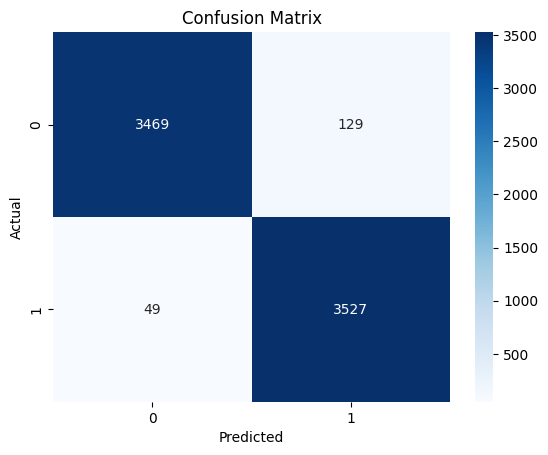

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3598
           1       0.96      0.99      0.98      3576

    accuracy                           0.98      7174
   macro avg       0.98      0.98      0.98      7174
weighted avg       0.98      0.98      0.98      7174



In [ ]:
import joblib
joblib.dump(scaler, "/content/drive/MyDrive/geolife_models/scaler1.pkl")

['/content/drive/MyDrive/geolife_models/scaler1.pkl']

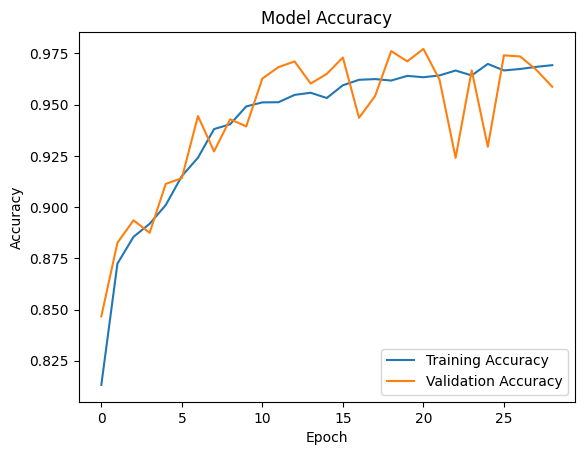

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

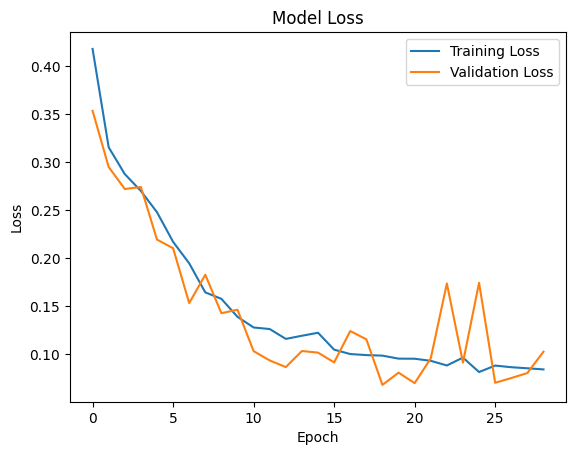

In [ ]:
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


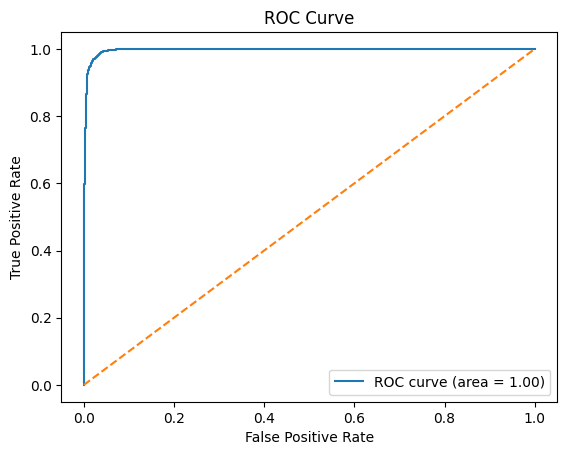

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
plt.savefig("/content/drive/MyDrive/geolife_models/roc_curve.png")

<Figure size 640x480 with 0 Axes>